<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/PHDS_thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **importing the dataset of all the 28 countries**

In [127]:
import pandas as pd
import gdown
file_id = '1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr'
output_filename = 'All.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_filename, quiet=False)
df = pd.read_csv(output_filename, encoding='latin1')
df.shape
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr
From (redirected): https://drive.google.com/uc?id=1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr&confirm=t&uuid=5e526ee1-286a-41c8-aa1b-76ed806a1800
To: /content/All.csv
100%|██████████| 131M/131M [00:01<00:00, 90.9MB/s]
/tmp/ipykernel_7303/2464451880.py:6: DtypeWarning: Columns (10,24,28,29,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_filename, encoding='latin1')


,caseid,v000,v001,v005,v007,v012,v021,v024,v025,v106,...,v754wp,v756,v761,v762,v763a,v763b,v763c,v766b,v781,v783
0,1 1 01,AO8,1,771031,2023,21,1,moxico,urban,secondary,...,NaN,NaN,NaN,NaN,no,no,no,0,no,NaN
1,1 2 02,AO8,1,771031,2023,20,1,moxico,urban,primary,...,NaN,NaN,no,NaN,no,no,no,1,no,NaN
2,1 3 02,AO8,1,771031,2023,21,1,moxico,urban,no education,...,no,yes,no,NaN,no,no,no,1,yes,NaN
3,1 4 02,AO8,1,771031,2023,19,1,moxico,urban,no education,...,NaN,NaN,no,NaN,no,no,no,1,no,NaN
4,1 7 01,AO8,1,771031,2023,32,1,moxico,urban,no education,...,NaN,NaN,no,NaN,no,no,no,1,no,NaN


# **Data Cleaning**

## **Total Number of samples in each country and year of Survey**

In [128]:
country_mapping = {
    'AO8': 'Angola',
    'BF8': 'Burkina Faso',
    'BJ7': 'Benin',
    'BU7': 'Burundi',
    'CD8': 'DR Congo',
    'CI8': 'Côte d’Ivoire',
    'CM7': 'Cameroon',
    'ET7': 'Ethiopia',
    'GA7': 'Gabon',
    'GH8': 'Ghana',
    'GM7': 'Gambia',
    'GN7': 'Guinea',
    'KE8': 'Kenya',
    'LB7': 'Liberia',
    'LS8': 'Lesotho',
    'MD7': 'Madagascar',
    'ML8': 'Mali',
    'MR7': 'Mauritania',
    'MW8': 'Malawi',
    'MZ8': 'Mozambique',
    'NG8': 'Nigeria',
    'RW7': 'Rwanda',
    'SL7': 'Sierra Leone',
    'SN8': 'Senegal',
    'TZ8': 'Tanzania',
    'UG7': 'Uganda',
    'ZA7': 'South Africa',
    'ZM8': 'Zambia'
}

# Rename the categories in the v000 column
df['v000'] = df['v000'].map(country_mapping).fillna(df['v000'])

# Display the unique values to confirm
print(df['v000'].unique())

['Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon' 'Côte d’Ivoire'
 'DR Congo' 'Ethiopia' 'Gabon' 'Gambia' 'Ghana' 'Guinea' 'Kenya' 'Lesotho'
 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mozambique'
 'Nigeria' 'Rwanda' 'Senegal' 'Sierra Leone' 'South Africa' 'Tanzania'
 'Uganda' 'Zambia']


In [129]:
df.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v024',
       'v025', 'v106', 'v130', 'v157', 'v158', 'v159', 'v169a', 'v171a',
       'v190', 'v228', 'v312', 'v394', 'v467a', 'v467b', 'v467c', 'v467d',
       'v481', 'v501', 'v525', 'v717', 'v751', 'v754bp', 'v754cp', 'v754dp',
       'v754jp', 'v754wp', 'v756', 'v761', 'v762', 'v763a', 'v763b', 'v763c',
       'v766b', 'v781', 'v783'],
      dtype='object')

### removing the who have no sexual intercourse history

In [130]:
# Show the count of 'not had sex' in v525 by country
print("Count of respondents who have 'not had sex' by country:")
never_had_sex_counts = df[df['v525'] == 'not had sex'].groupby('v000').size()
print(never_had_sex_counts)

# Remove rows where age_first_sex is 'not had sex'
initial_shape = df.shape
df = df[df['v525'] != 'not had sex']
new_shape = df.shape

print(f"\nRows removed: {initial_shape[0] - new_shape[0]}")
print(f"New dataset shape: {new_shape}")

Count of respondents who have 'not had sex' by country:
v000
Angola           1882
Benin            1953
Burkina Faso     2523
Burundi          5256
Cameroon         2058
Côte d’Ivoire    1663
DR Congo         4211
Ethiopia         3721
Gabon            1086
Gambia           3041
Ghana            2017
Guinea           1712
Kenya            5258
Lesotho           727
Liberia           490
Madagascar       2046
Malawi           2563
Mali             2623
Mauritania         34
Mozambique       1222
Nigeria          7454
Rwanda           4044
Senegal          4450
Sierra Leone     1609
South Africa     1038
Tanzania         2527
Uganda           2671
Zambia           1707
dtype: int64

Rows removed: 71586
New dataset shape: (394010, 43)


In [131]:
# Reshape the data from wide to long format
tabulation_table = pd.crosstab(df['v000'], df['v007'])
reshaped_df = tabulation_table.stack().reset_index()
reshaped_df.columns = ['Country', 'Year of Survey', 'Total Survey']
reshaped_df = reshaped_df[reshaped_df['Total Survey'] > 0].reset_index(drop=True)

# Group any number of consecutive years for the same country
def merge_consecutive_years(group):
    # The group name (Country) is available via the name attribute when using apply
    country_name = group.name
    group = group.sort_values('Year of Survey')
    merged = []
    if group.empty:
        return pd.DataFrame(merged)

    i = 0
    while i < len(group):
        current_years = [str(group.iloc[i]['Year of Survey'])]
        total_survey = group.iloc[i]['Total Survey']

        j = i + 1
        while j < len(group) and group.iloc[j]['Year of Survey'] == group.iloc[j-1]['Year of Survey'] + 1:
            current_years.append(str(group.iloc[j]['Year of Survey']))
            total_survey += group.iloc[j]['Total Survey']
            j += 1

        merged.append({
            'Country': country_name,
            'Year of Survey': '/'.join(current_years),
            'Total Survey': total_survey
        })
        i = j
    return pd.DataFrame(merged)

final_df = reshaped_df.groupby('Country', group_keys=False).apply(merge_consecutive_years, include_groups=False).reset_index(drop=True)
print(final_df)

# Save the final dataframe as a csv
final_df.to_csv('survey_summary.csv', index=False)
print("\nFile saved as survey_summary.csv")

          Country  Year of Survey  Total Survey
0          Angola       2023/2024         12835
1           Benin       2017/2018         13975
2    Burkina Faso            2021         15136
3         Burundi       2016/2017         12013
4        Cameroon       2018/2019         12619
5   Côte d’Ivoire            2021         13214
6        DR Congo       2023/2024         23372
7        Ethiopia            2008         11962
8           Gabon  2019/2020/2021          9957
9          Gambia       2019/2020          8824
10          Ghana       2022/2023         12997
11         Guinea            2018          9162
12          Kenya            2022         26898
13        Lesotho       2023/2024          5686
14        Liberia       2019/2020          7575
15     Madagascar            2021         16823
16         Malawi            2024         19024
17           Mali       2023/2024         17731
18     Mauritania  2019/2020/2021         15680
19     Mozambique       2022/2023       

## Missing Values management

### the missing values more than 20% were removed

In [132]:
# Calculate the percentage of missing values for each column
missing_percent = (df.isnull().sum() / len(df)) * 100

# Identify columns to remove (missing values > 20%)
cols_to_remove = missing_percent[missing_percent > 20].index.tolist()

print(f"Columns with >20% missing values: {cols_to_remove}")

# Drop these columns
df = df.drop(columns=cols_to_remove)

print(f"\nRemoved {len(cols_to_remove)} columns.")
print(f"New dataframe shape: {df.shape}")

# Show remaining missing values if any
remaining_missing = (df.isnull().sum() / len(df)) * 100
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("\nRemaining missing values (<= 20%):")
print(remaining_missing if not remaining_missing.empty else "No missing values remaining.")

Columns with >20% missing values: ['v467a', 'v751', 'v754bp', 'v754cp', 'v754dp', 'v754jp', 'v754wp', 'v756', 'v762', 'v783']

Removed 10 columns.
New dataframe shape: (394010, 33)

Remaining missing values (<= 20%):
v761     17.817314
v481      9.583006
v130      9.107129
v766b     8.026954
v763b     7.655643
v763c     7.655643
v394      6.238420
v467d     6.003655
v467b     6.003655
v467c     6.003655
v763a     5.122713
v781      4.047359
v525      1.877364
v312      1.481688
v228      1.481688
v717      1.198447
v501      0.799980
v190      0.142128
v157      0.002030
dtype: float64


In [133]:
df.head()

,caseid,v000,v001,v005,v007,v012,v021,v024,v025,v106,...,v481,v501,v525,v717,v761,v763a,v763b,v763c,v766b,v781
0,1 1 01,Angola,1,771031,2023,21,1,moxico,urban,secondary,...,no,living with partner,19,not working,NaN,no,no,no,0,no
1,1 2 02,Angola,1,771031,2023,20,1,moxico,urban,primary,...,no,living with partner,19,not working,no,no,no,no,1,no
2,1 3 02,Angola,1,771031,2023,21,1,moxico,urban,no education,...,no,living with partner,15,not working,no,no,no,no,1,yes
3,1 4 02,Angola,1,771031,2023,19,1,moxico,urban,no education,...,no,living with partner,11,not working,no,no,no,no,1,no
4,1 7 01,Angola,1,771031,2023,32,1,moxico,urban,no education,...,no,no longer living together/separated,15,not working,no,no,no,no,1,no


In [134]:
df.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v024',
       'v025', 'v106', 'v130', 'v157', 'v158', 'v159', 'v169a', 'v171a',
       'v190', 'v228', 'v312', 'v394', 'v467b', 'v467c', 'v467d', 'v481',
       'v501', 'v525', 'v717', 'v761', 'v763a', 'v763b', 'v763c', 'v766b',
       'v781'],
      dtype='object')

In [135]:
df = df.rename(columns={
    "caseid": "case_id",
    "v000": "country",
    "v001": "cluster_cluster",
    "v005": "sample_weight",
    "v007": "survey_year",
    "v012": "Maternal_age",
    "v021": "psu",
    "v024": "region",
    "v025": "residence",
    "v106": "education_level",
    "v130": "religion",
    "v157": "reads_newspaper",
    "v158": "listens_radio",
    "v159": "watches_tv",
    "v169a": "owns_mobile_phone",
    "v171a": "uses_internet",
    "v190": "wealth_index",
    "v228": "ever_terminated_pregnancy",
    "v312": "contraceptive_method",
    "v394": "visited_HF-in last12_months",
    "v481": "Health_insurance_coverage",
    "v501": "marital_status",
    "v525": "age_first_sex",
    "v717": "Occupation_status",
    "v763a": "had_any_STI_in12months",
    "v763b": "genital_ulcer_in12months",
    "v763c": "genital_discharge_in12months",
    "v766b": "number_sexual_partner_12months",
    "v781": "ever_tested_for_HIV"
})

In [136]:
df.head()

,case_id,country,cluster_cluster,sample_weight,survey_year,Maternal_age,psu,region,residence,education_level,...,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,v761,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV
0,1 1 01,Angola,1,771031,2023,21,1,moxico,urban,secondary,...,no,living with partner,19,not working,NaN,no,no,no,0,no
1,1 2 02,Angola,1,771031,2023,20,1,moxico,urban,primary,...,no,living with partner,19,not working,no,no,no,no,1,no
2,1 3 02,Angola,1,771031,2023,21,1,moxico,urban,no education,...,no,living with partner,15,not working,no,no,no,no,1,yes
3,1 4 02,Angola,1,771031,2023,19,1,moxico,urban,no education,...,no,living with partner,11,not working,no,no,no,no,1,no
4,1 7 01,Angola,1,771031,2023,32,1,moxico,urban,no education,...,no,no longer living together/separated,15,not working,no,no,no,no,1,no


### **Recategorize country based on the geographic region**

In [137]:
region_map = {
    # West Africa
    "Benin": "West Africa",
    "Burkina Faso": "West Africa",
    "Côte d’Ivoire": "West Africa",
    "Gambia": "West Africa",
    "Ghana": "West Africa",
    "Guinea": "West Africa",
    "Liberia": "West Africa",
    "Mali": "West Africa",
    "Mauritania": "West Africa",
    "Nigeria": "West Africa",
    "Senegal": "West Africa",
    "Sierra Leone": "West Africa",

    # East Africa
    "Burundi": "East Africa",
    "Ethiopia": "East Africa",
    "Kenya": "East Africa",
    "Rwanda": "East Africa",
    "Tanzania": "East Africa",
    "Uganda": "East Africa",

    # Central Africa
    "Cameroon": "Central Africa",
    "Gabon": "Central Africa",
    "DR Congo": "Central Africa",

    # Southern Africa
    "Angola": "Southern Africa",
    "Lesotho": "Southern Africa",
    "Madagascar": "Southern Africa",
    "Malawi": "Southern Africa",
    "Mozambique": "Southern Africa",
    "South Africa": "Southern Africa",
    "Zambia": "Southern Africa"
}

# Apply mapping
df['Geographic_region'] = df['country'].map(region_map)


In [138]:
df.columns

Index(['case_id', 'country', 'cluster_cluster', 'sample_weight', 'survey_year',
       'Maternal_age', 'psu', 'region', 'residence', 'education_level',
       'religion', 'reads_newspaper', 'listens_radio', 'watches_tv',
       'owns_mobile_phone', 'uses_internet', 'wealth_index',
       'ever_terminated_pregnancy', 'contraceptive_method',
       'visited_HF-in last12_months', 'v467b', 'v467c', 'v467d',
       'Health_insurance_coverage', 'marital_status', 'age_first_sex',
       'Occupation_status', 'v761', 'had_any_STI_in12months',
       'genital_ulcer_in12months', 'genital_discharge_in12months',
       'number_sexual_partner_12months', 'ever_tested_for_HIV',
       'Geographic_region'],
      dtype='object')

In [139]:
columns_to_keep = [
    'country','Maternal_age', 'residence', 'education_level',
    'reads_newspaper', 'listens_radio', 'watches_tv',
    'owns_mobile_phone', 'uses_internet', 'wealth_index',
    'ever_terminated_pregnancy', 'contraceptive_method',
    'visited_HF-in last12_months', 'v467b', 'v467c', 'v467d',
    'Health_insurance_coverage', 'marital_status', 'age_first_sex',
    'Occupation_status', 'had_any_STI_in12months',
    'genital_ulcer_in12months', 'genital_discharge_in12months',
    'number_sexual_partner_12months', 'ever_tested_for_HIV',
    'Geographic_region'
]

# Filter the dataframe to the selected columns
df = df[columns_to_keep]

# Display the first few rows to confirm
df.head()

,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,...,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,...,no,living with partner,19,not working,no,no,no,0,no,Southern Africa
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,...,no,living with partner,19,not working,no,no,no,1,no,Southern Africa
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,...,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,...,no,living with partner,11,not working,no,no,no,1,no,Southern Africa
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,...,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa


### Creating Media exposure feature

In [140]:
media_cols = ['reads_newspaper', 'listens_radio', 'watches_tv']

# Map responses to check for 'at least once a week' exposure
# Standard DHS responses: 'at least once a week' and 'almost every day' count as exposure
def check_exposure(val):
    if pd.isna(val):
        return 0
    if str(val).lower() in ['at least once a week', 'almost every day']:
        return 1
    return 0

# Create individual exposure flags
for col in media_cols:
    df[f'exp_{col}'] = df[col].apply(check_exposure)

# Media exposure = 1 if exposed to at least one form within a week, else 0
df['Media_exposure'] = df[[f'exp_{col}' for col in media_cols]].max(axis=1)

# Drop intermediate calculation columns
df = df.drop(columns=[f'exp_{col}' for col in media_cols])

# Show results as percentages
print("Media Exposure Percentages:")
print(df['Media_exposure'].value_counts(normalize=True) * 100)
df.head()

Media Exposure Percentages:
Media_exposure
0    52.459075
1    47.540925
Name: proportion, dtype: float64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,...,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,...,living with partner,19,not working,no,no,no,0,no,Southern Africa,0
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,...,living with partner,19,not working,no,no,no,1,no,Southern Africa,0
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,...,living with partner,15,not working,no,no,no,1,yes,Southern Africa,0
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,...,living with partner,11,not working,no,no,no,1,no,Southern Africa,0
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,...,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa,0


In [141]:
df.columns

Index(['country', 'Maternal_age', 'residence', 'education_level',
       'reads_newspaper', 'listens_radio', 'watches_tv', 'owns_mobile_phone',
       'uses_internet', 'wealth_index', 'ever_terminated_pregnancy',
       'contraceptive_method', 'visited_HF-in last12_months', 'v467b', 'v467c',
       'v467d', 'Health_insurance_coverage', 'marital_status', 'age_first_sex',
       'Occupation_status', 'had_any_STI_in12months',
       'genital_ulcer_in12months', 'genital_discharge_in12months',
       'number_sexual_partner_12months', 'ever_tested_for_HIV',
       'Geographic_region', 'Media_exposure'],
      dtype='object')

### processing the outcome variables (self report of STI)

In [142]:
sti_cols = ['had_any_STI_in12months', 'genital_ulcer_in12months', 'genital_discharge_in12months']

for col in sti_cols:
    print(f"--- Frequency distribution for {col} ---")
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents})
    display(summary)
    print("\n")

--- Frequency distribution for had_any_STI_in12months ---


,Count,Percentage (%)
had_any_STI_in12months,,
no,347221,88.124921
yes,25994,6.597294
NaN,20184,5.122713
don't know,611,0.155072




--- Frequency distribution for genital_ulcer_in12months ---


,Count,Percentage (%)
genital_ulcer_in12months,,
no,333551,84.655466
NaN,30164,7.655643
yes,28361,7.198041
don't know,1934,0.490850




--- Frequency distribution for genital_discharge_in12months ---


,Count,Percentage (%)
genital_discharge_in12months,,
no,309283,78.496231
yes,52659,13.364889
NaN,30164,7.655643
don't know,1904,0.483236


In [143]:
# Define the STI indicator columns
sti_cols = ['had_any_STI_in12months', 'genital_discharge_in12months', 'genital_ulcer_in12months']

# Create a function to categorize STI status
def categorize_sti(row):
    # Extract values and convert to lowercase for consistent comparison
    vals = [str(row[col]).lower() for col in sti_cols if pd.notna(row[col])]
    if 'yes' in vals:
        return 1
    return 0

# Apply the function to create the dummy coded 'STI' variable
df['STI'] = df.apply(categorize_sti, axis=1)

# Show the results
print("Frequency distribution for the new 'STI' variable (0 = No, 1 = Yes):")
print(df['STI'].value_counts())
print("\nPercentage distribution:")
print(df['STI'].value_counts(normalize=True) * 100)

df.head()

Frequency distribution for the new 'STI' variable (0 = No, 1 = Yes):
STI
0    324531
1     69479
Name: count, dtype: int64

Percentage distribution:
STI
0    82.366184
1    17.633816
Name: proportion, dtype: float64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,...,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,...,19,not working,no,no,no,0,no,Southern Africa,0,0
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,...,19,not working,no,no,no,1,no,Southern Africa,0,0
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,...,15,not working,no,no,no,1,yes,Southern Africa,0,0
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,...,11,not working,no,no,no,1,no,Southern Africa,0,0
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,...,15,not working,no,no,no,1,no,Southern Africa,0,0


#### SR STI by country

In [144]:
# Re-attach the country column from the original mapping context if necessary
# Since df was filtered to columns_to_keep, ensure 'country' or its alias is available.
# In cell 7893W3eyTqUP, v000 was renamed to 'country'.

# Calculate the percentage of STI = 1 by country
sti_by_country = df.groupby('country')['STI'].mean() * 100

# Sort for better visualization
sti_by_country = sti_by_country.sort_values(ascending=False).reset_index()
sti_by_country.columns = ['Country', 'STI Percentage (%)']

print("Percentage of reported STI by Country:")
print(sti_by_country)

Percentage of reported STI by Country:
          Country  STI Percentage (%)
0         Liberia           45.201320
1            Mali           34.893689
2          Guinea           33.355163
3           Ghana           26.952374
4   Côte d’Ivoire           25.238384
5          Uganda           23.593306
6        DR Congo           23.515317
7    Sierra Leone           21.439313
8          Angola           21.106350
9         Lesotho           21.016532
10   Burkina Faso           19.985465
11         Malawi           18.587048
12        Senegal           18.536224
13     Mauritania           17.653061
14     Mozambique           17.598863
15       Cameroon           17.006102
16        Nigeria           16.052665
17       Tanzania           13.255284
18         Rwanda           13.182247
19   South Africa           12.734082
20         Gambia           12.296011
21        Burundi           10.613502
22          Gabon           10.374611
23         Zambia            8.910487
24         

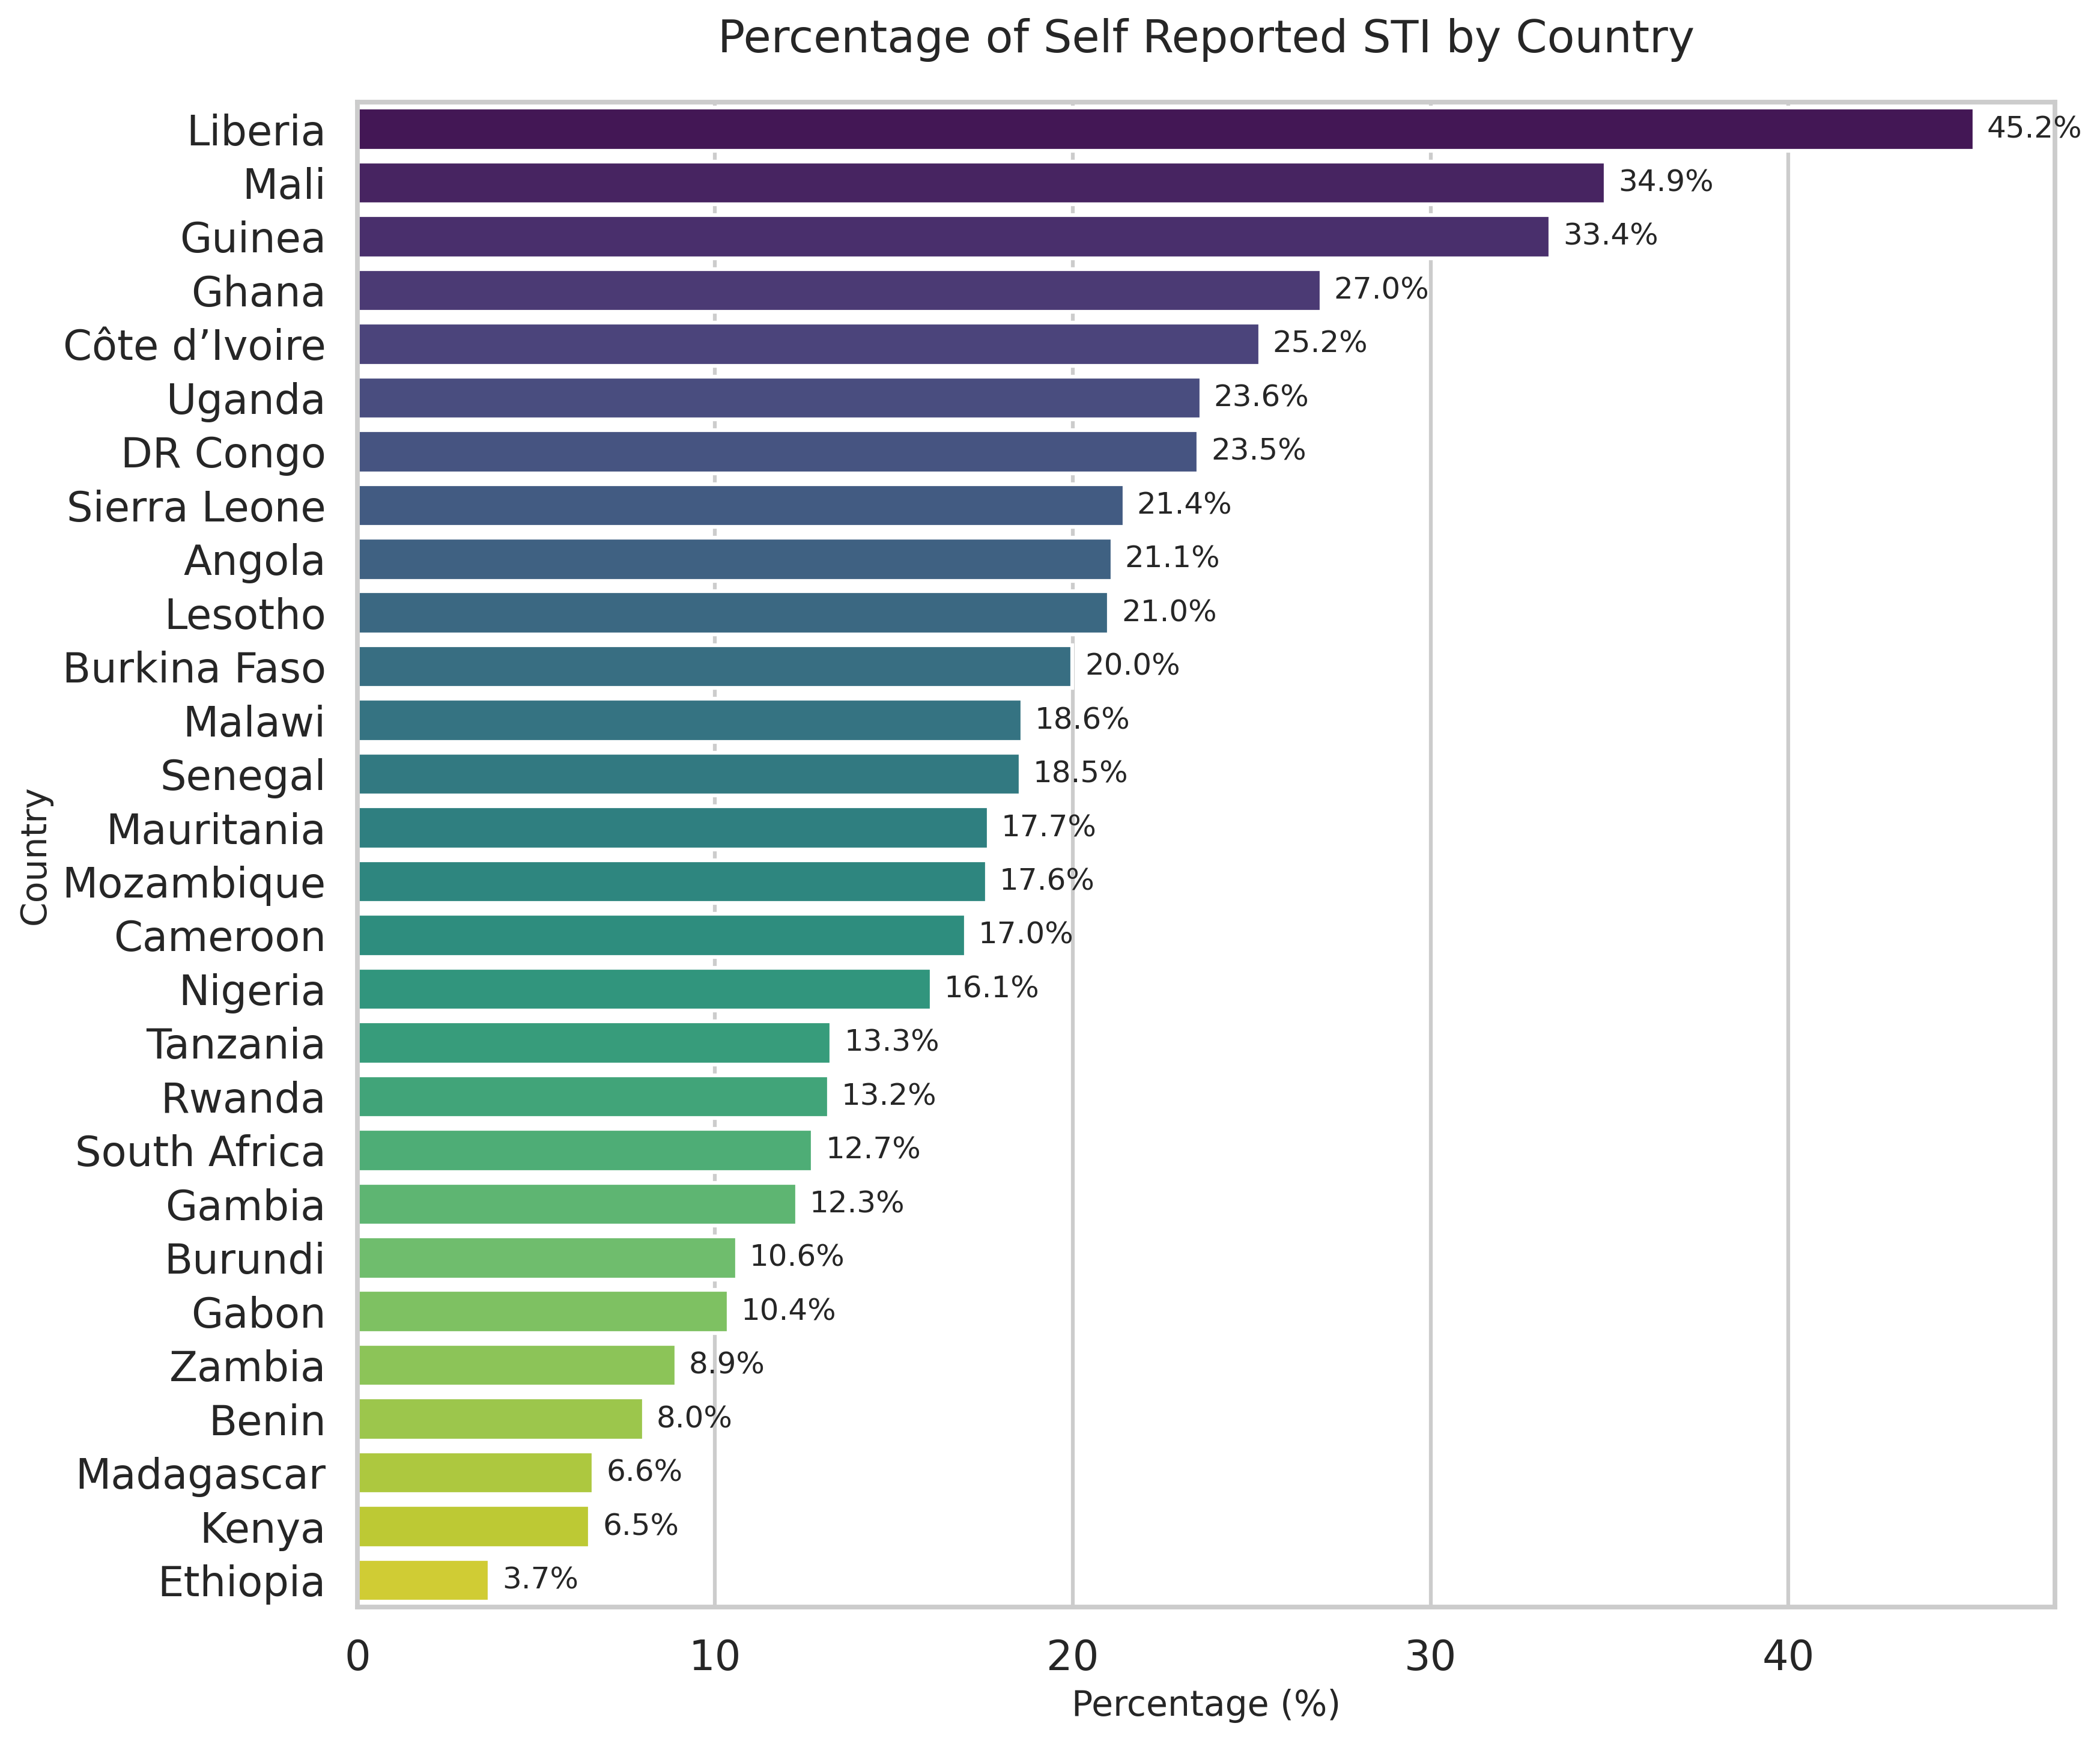

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and context for high quality
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.figure(figsize=(12, 10), dpi=300)

# Create the bar plot
# Note: Assigned hue='Country' to avoid the FutureWarning while keeping the palette
ax = sns.barplot(
    data=sti_by_country,
    y='Country',
    x='STI Percentage (%)',
    palette='viridis',
    hue='Country',
    legend=False
)

# Add labels and title
plt.title('Percentage of Self Reported STI by Country', fontsize=18, pad=20)
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# Add data labels on the bars with better formatting
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5, fontsize=12)

plt.tight_layout()
plt.show()

### Creating Healthcare access problem feature

### Creating Media Exposure composite variable